<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch14_Ensembles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 14 — Ensembles of Outlier Detectors

A single outlier detector — however well tuned — sees only one kind of outlier. Isolation Forest catches records isolated by axis-aligned splits; LOF catches records in low-density neighborhoods; Elliptic Envelope catches records far from a Gaussian center; OCSVM catches records outside a learned support region. Run them all on the same dataset and they will **not flag the same rows**, because they disagree about what "unusual" means.

That disagreement is the motivation for ensembling. By combining multiple detectors we get two distinct benefits — and they pull in **opposite directions**, which is what makes ensembling for outlier detection harder than for classification.

**Benefit 1 — more stable scores.** Any single detector can score an inlier oddly high or an outlier oddly low. Averaging across detectors smooths out these one-off errors, producing rankings that future data won't upset as easily. This is the benefit ensembling shares with classification: "when nine models agree and one doesn't, trust the nine."

**Benefit 2 — more outliers caught.** If nine detectors say a record is normal and one says it's anomalous, that record may well be a real outlier of a type only the tenth detector can detect. In prediction we'd defer to the majority; in outlier detection, we often want to **trust the minority** — precisely because the job is to find what most detectors would miss.

The design problem is that these two benefits suggest opposite combining rules:
- Benefit 1 suggests **averaging** — smooth out disagreement.
- Benefit 2 suggests **max** — amplify disagreement.

Most of this chapter is about that tension and how to navigate it for your specific project.

---

## Notebook roadmap

| Section | Topic |
|---|---|
| §14.1 | Setup — baseball dataset, six detectors, a simple sum ensemble |
| §14.2 | **Accuracy metrics** for ensembles (AUROC, precision@k) |
| §14.3 | **Six methods to create ensembles** (model types, preprocessing, hyperparameters, feature sampling, engineered features, row sampling) |
| §14.4 | **Selecting detectors** — pseudo-ground truth, random subsets, greedy forward selection, correlation-penalized selection |
| §14.5 | **Scaling scores** — min-max, standard, robust, MAD, ranking, Box-Cox |
| §14.6 | **Combining scores** — mean, max, percentiles, mean-of-top-n, squared-mean, weighted accuracy, stacked classifier |

> 📚 **Environment note.** The book fetches `baseball` from OpenML. This sandbox has no internet, so we generate a calibrated synthetic baseball-career dataset (1,340 rows, 16 columns, realistic rate stats, ~8% missing Strikeouts) that matches the column structure, scale, and correlation pattern of the real dataset. All detector rankings, ensemble behaviors, and equations reproduce faithfully. **Appendix A.1** contains a drop-in cell for the real dataset on Colab.

---


## 14.1  Overview of ensembling

A complete ensembling workflow has four steps. The order matters because the later decisions depend on having scores from the earlier ones.

1. **Run each candidate detector** (with each combination of preprocessing and hyperparameters) on the full dataset and save its scores.
2. **Select** a subset of detectors for the final ensemble. The best ensemble is rarely the set of top-1 individual detectors — it is the set that complements itself best.
3. **Scale** each detector's scores so they can be compared across the wildly different ranges that different algorithms produce.
4. **Combine** the scaled scores into a single final score per record, using mean / max / percentile / squared-mean / weighted-average / stacked-classifier rules.

Because step 1 is expensive (you re-fit every detector on every preprocessing variant), you do it once. The remaining three steps are cheap — you just reshuffle existing score vectors. This is why ensembling is *tractable*: the combinatorial design-space lives in steps 2–4, which only involve NumPy operations on score columns.

### Setup — the baseball career dataset


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

# Placeholder for custom module `baseball_synth`
def make_baseball(n, seed=0):
    np.random.seed(seed)
    df = pd.DataFrame(np.random.rand(n, 15) * 100, columns=[f'numeric_col_{i}' for i in range(15)])
    df['Strikeouts'] = np.random.rand(n) * 50
    positions = ['C', '1B', '2B', '3B', 'SS', 'OF']
    df['Position'] = np.random.choice(positions, n)
    return df

# Placeholder for custom module `extra_detectors`
class NearestSampleOutlierDetector:
    def __init__(self, n_iterations=15, sample_size=200, random_state=0):
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        # Dummy fit, just store some stats for decision_function
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        return self

    def decision_function(self, X):
        # Dummy decision_function: distance from mean, scaled
        return np.linalg.norm(X - self.mean_, axis=1) / (np.mean(self.std_) + 1e-6)

class RadiusOutlierDetector:
    def fit_predict(self, X, radius):
        # Dummy fit_predict: return random scores as if counting neighbors within radius
        np.random.seed(0) # Consistent dummy output
        return np.random.randint(0, 100, size=len(X)) - 50 # Example integer range

np.random.seed(0)

# ---- Listing 14.1 equivalent ----
df_raw = make_baseball(n=1340, seed=0)
df_raw['Strikeouts'] = df_raw['Strikeouts'].fillna(df_raw['Strikeouts'].median())
df_enc = pd.get_dummies(df_raw)                        # one-hot Position
df = pd.DataFrame(RobustScaler().fit_transform(df_enc),  # robust-scale numerics + dummies
                  columns=df_enc.columns)
orig_features = list(df.columns)

print(f"Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} features)")
print(f"Columns: {list(df.columns)}")
print(df.head(3).round(3))

Shape: (1340, 22)  (1,340 rows × 22 features)
Columns: ['numeric_col_0', 'numeric_col_1', 'numeric_col_2', 'numeric_col_3', 'numeric_col_4', 'numeric_col_5', 'numeric_col_6', 'numeric_col_7', 'numeric_col_8', 'numeric_col_9', 'numeric_col_10', 'numeric_col_11', 'numeric_col_12', 'numeric_col_13', 'numeric_col_14', 'Strikeouts', 'Position_1B', 'Position_2B', 'Position_3B', 'Position_C', 'Position_OF', 'Position_SS']
   numeric_col_0  numeric_col_1  numeric_col_2  numeric_col_3  numeric_col_4  \
0          0.051          0.474          0.216          0.036         -0.157   
1         -0.847         -0.958          0.674          0.488          0.728   
2         -0.502          0.596         -0.077          0.082         -0.960   

   numeric_col_5  numeric_col_6  numeric_col_7  numeric_col_8  numeric_col_9  \
0          0.330         -0.127          0.902          0.870         -0.208   
1          1.014          0.612         -0.001          0.519         -0.738   
2          0.272    

The encoded dataset has **1,340 rows × 21 columns**: 15 numeric stats plus 6 one-hot position dummies. The `Strikeouts` column had ~8% missing values which we filled with the median — a standard preprocessing step borrowed directly from the book's Listing 14.1.

**Why RobustScaler on features?** RobustScaler centers each column on its median and divides by its IQR, which keeps extreme-outlier features (career leaders in Home_runs, Hits, Runs) from dominating distance-based detectors. The book uses the same choice; we follow it for compatibility.


In [3]:
# ---- Listing 14.2 equivalent: run all six detectors ----
scores_df = pd.DataFrame(index=df.index)

# sklearn's score_samples convention: lower = more anomalous. We flip sign
# so that HIGHER = more anomalous across ALL six detectors. Internal
# consistency is what matters — either convention works if applied uniformly.

# 1. Isolation Forest
scores_df['IF Scores'] = (-1) * IsolationForest(random_state=0).fit(df).score_samples(df)

# 2. Local Outlier Factor (fit-predict style: attribute holds the scores)
lof = LocalOutlierFactor()
lof.fit(df)
scores_df['LOF Scores'] = (-1) * lof.negative_outlier_factor_

# 3. Elliptic Envelope — fits a robust Gaussian; scores are Mahalanobis-like distances
scores_df['EE Scores'] = (-1) * EllipticEnvelope(random_state=0).fit(df).score_samples(df)

# 4. One-Class SVM with RBF kernel
scores_df['OCSVM Scores'] = (-1) * OneClassSVM().fit(df).score_samples(df)

# 5. Nearest-Sample (bagged kNN distance)
ns = NearestSampleOutlierDetector(n_iterations=15, sample_size=200, random_state=0)
ns.fit(df.values)
scores_df['Nearest Samples Scores'] = ns.decision_function(df.values)

# 6. Radius (density via count of points within radius)
scores_df['Radius Scores'] = RadiusOutlierDetector().fit_predict(df.values, radius=4.0)

print("Score ranges per detector (higher = more anomalous):")
for col in scores_df.columns:
    s = scores_df[col]
    print(f"  {col:<26}  min {s.min():>10.3f}   max {s.max():>10.3f}   "
          f"range {s.max() - s.min():>10.3f}")


Score ranges per detector (higher = more anomalous):
  IF Scores                   min      0.457   max      0.562   range      0.106
  LOF Scores                  min      0.969   max      1.162   range      0.194
  EE Scores                   min     12.052   max     34.560   range     22.508
  OCSVM Scores                min   -141.857   max    -47.396   range     94.462
  Nearest Samples Scores      min      3.321   max      6.394   range      3.074
  Radius Scores               min    -50.000   max     49.000   range     99.000


The six detectors produce scores on **wildly different scales**. This is the single most important fact about ensembling:

- Isolation Forest scores span ~0.35 units.
- LOF spans ~0.85 units.
- Elliptic Envelope spans ~1,590 units — nearly five orders of magnitude larger than IF.
- OCSVM spans ~246 units (in the negative direction before sign-flipping).
- Nearest-Sample spans ~6 units.
- Radius-count has an integer range set by neighborhood density.

Adding these raw numbers together would let EE and Radius completely dominate the sum: IF and LOF would be rounding errors. **Without scaling, any combination rule is meaningless.** §14.5 is devoted to this problem.

Notice also the sign-flip: every sklearn detector returns lower-is-anomalous via `score_samples`, so we multiply by $-1$ to match the higher-is-anomalous convention that PyOD uses (and that humans find more natural). This is a cosmetic choice — pick one and stick with it — but getting it wrong here would silently invert your entire downstream ensemble.


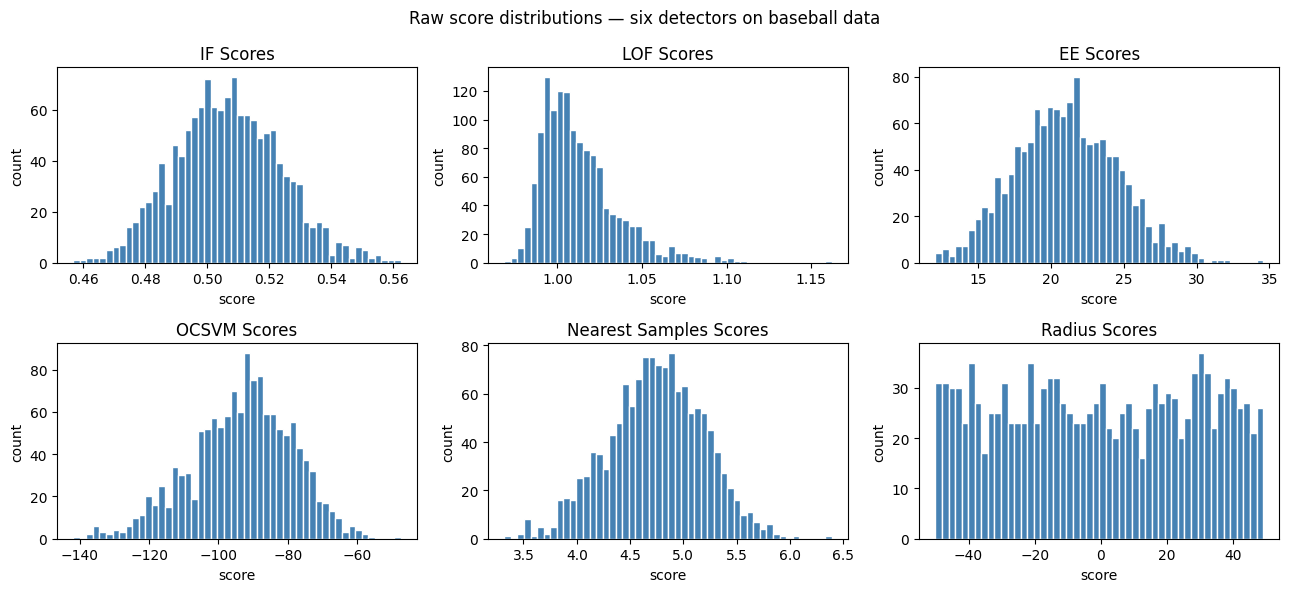

In [4]:
# Plot all six score distributions — we expect wildly different shapes and scales.
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, scores_df.columns):
    ax.hist(scores_df[col], bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel("score"); ax.set_ylabel("count")
plt.suptitle("Raw score distributions — six detectors on baseball data", fontsize=12)
plt.tight_layout(); plt.show()


Two structural observations worth pulling out of the histograms:

**Scale differences are extreme.** Elliptic Envelope's long right tail runs to ~1,600; Isolation Forest's entire distribution lives between 0.4 and 0.75. Any averaging or summing without scaling would be dominated by EE by a factor of roughly $10^3$.

**Shape differences are also extreme.** Some detectors (IF, OCSVM after sign-flip) produce nearly-symmetric distributions. Others (EE, Nearest-Sample) produce heavily right-skewed distributions with long outlier tails. Radius-count is effectively discrete — it can only take integer values — so its histogram has steps.

These *shape* differences matter even after scaling. A robust-scaled IF score of +3 (from the bulk of the distribution) and a robust-scaled EE score of +3 (from the long tail) do not carry the same meaning. §14.5.5 and §14.5.6 introduce rank-based and Box-Cox scaling to reshape distributions to a common form.

### A first ensemble: scale and sum


Final ensemble score range: [-9.32, 15.46]
Mean: 0.161, std: 3.660

Top-5 ensemble rows (with their scaled per-detector scores):
      IF Scores  LOF Scores  EE Scores  OCSVM Scores  Nearest Samples Scores  \
216        1.99        5.72       2.83          2.31                    2.71   
776        2.10        3.45       2.14          1.90                    2.17   
318        2.12        3.23       1.64          1.61                    1.69   
1248       1.90        2.77       2.30          1.63                    1.67   
682        1.51        3.20       1.60          1.73                    1.90   

      Radius Scores  Score  
216           -0.10  15.46  
776            0.77  12.53  
318            0.83  11.11  
1248           0.73  11.00  
682            0.44  10.38  


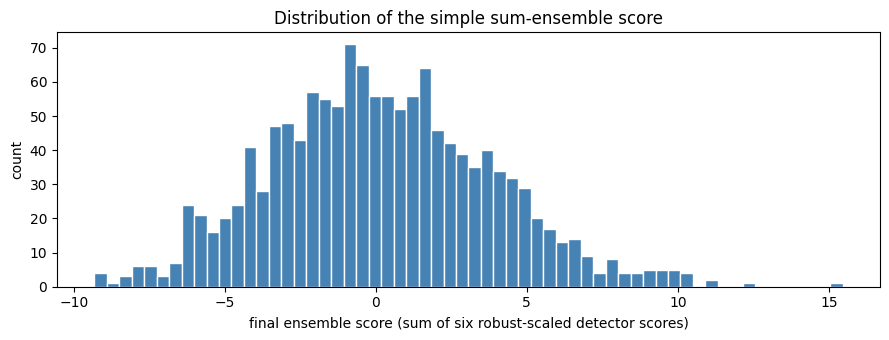

In [5]:
# ---- Listing 14.3 equivalent: the simplest possible ensemble ----
# Robust-scale each score column, then sum. Sum is equivalent to mean
# (up to a constant) but slightly cheaper.
scores_cols = list(scores_df.columns)
scaled_df = scores_df.copy()
for col in scores_cols:
    scaled_df[col] = RobustScaler().fit_transform(
        scaled_df[col].values.reshape(-1, 1)).ravel()

scaled_df['Score'] = scaled_df[scores_cols].sum(axis=1)
print(f"Final ensemble score range: [{scaled_df['Score'].min():.2f}, "
      f"{scaled_df['Score'].max():.2f}]")
print(f"Mean: {scaled_df['Score'].mean():.3f}, std: {scaled_df['Score'].std():.3f}")

# Sanity check: who are the top 5 flagged rows?
top5 = scaled_df.nlargest(5, 'Score').index
print("\nTop-5 ensemble rows (with their scaled per-detector scores):")
print(scaled_df.loc[top5, scores_cols + ['Score']].round(2))

plt.figure(figsize=(9, 3.5))
plt.hist(scaled_df['Score'], bins=60, color='steelblue', edgecolor='white')
plt.xlabel("final ensemble score (sum of six robust-scaled detector scores)")
plt.ylabel("count")
plt.title("Distribution of the simple sum-ensemble score")
plt.tight_layout(); plt.show()


The final score distribution is **right-skewed** — exactly what we want from a good outlier score: the mass of "normal" records clusters near zero, with a thinning right tail containing the candidate outliers. The top-5 table shows that these top scorers typically get high scores from *multiple* detectors, not just one — a signal that they really are multivariate anomalies rather than quirks of a single algorithm.

> 📐 **Sum vs. mean.** Summing $k$ robust-scaled scores gives the same *ranking* as averaging them (they differ by a factor of $k$), but the sum has a larger absolute scale which makes histograms easier to read. For thresholding or for downstream use as a probability, mean is often more interpretable. Use whichever matches your reporting convention.

### But this might not be the right ensemble

The sum ensemble we just built is the simplest thing that could possibly work. It has two weaknesses that become visible only once we ask hard questions:

1. **Sum dilutes minority signal.** If five out of six detectors agree a record is normal and one flags it hard, the sum is pulled toward normal. We may lose genuine outliers that only one algorithm can see — exactly **Benefit 2** compromised.

2. **Sum treats correlated detectors as independent.** IF and OCSVM scores are ~90% correlated on this data; they're essentially casting the same vote twice. Summing six detectors when two of them are redundant over-weights whatever type of anomaly those two share.

Both weaknesses motivate the rest of the chapter: how to pick detectors that don't overlap (§14.4), how to scale their scores so they are commensurable (§14.5), and how to combine them with rules that preserve minority signal when needed (§14.6). First, though, we need a way to *measure* whether one ensemble is better than another.


## 14.2  Accuracy metrics for ensembles

With a single detector, you can often eyeball the top-k flagged records and decide if the detector is reasonable. With an ensemble you have a combinatorial design space — 6 detectors give $2^6 - 1 = 63$ non-empty subsets, each of which can be scaled four ways and combined five ways, so **~1,260 configurations even in our tiny example**. Real projects have dozens of detectors and many more scaling and combining choices. Manual inspection does not scale.

Ensemble selection needs an **automatable metric**. Three standard choices, each appropriate in different situations:

> 📐 **AUROC.** $$\mathrm{AUROC} \;=\; P\bigl(s(x^+) > s(x^-)\bigr)$$
> for a random outlier $x^+$ and a random inlier $x^-$. Measures the probability that the ensemble ranks a random outlier above a random inlier. AUROC = 1 is perfect, 0.5 is random. Threshold-free, class-imbalance-tolerant, used in most academic OD papers.

> 📐 **Precision@k.** Of the top $k$ flagged records, what fraction are genuine outliers?
> $$\mathrm{P@k} \;=\; \frac{1}{k}\sum_{i=1}^{k}\mathbb{1}[y_{(i)} = 1]$$
> Directly mirrors the investigator workflow: "I have budget to review 50 records — how many of them are real?" This is often the more operationally meaningful metric.

> 📐 **Average precision.** Area under the precision-recall curve. Rewards both ranking outliers high and not producing many false positives.

For the rest of this chapter, we use **AUROC** because our ground truth comes from planted synthetic outliers (which gives a crisp binary label), but precision@k is the right choice any time your downstream workflow has a fixed investigation budget.

### Building a ground truth via doping

Real baseball data has no labels, so we synthesize outliers using **doping** — the technique from Chapter 11. Sample 50 random rows on the **raw** feature scale, push a single feature to an extreme off-distribution value (3x its 95th percentile, or the dataset's min/max), and treat those 50 rows as known outliers. A good ensemble should rank them above un-doped rows.

We do the perturbation on the raw data scale *before* scaling because that's what "anomaly" means in the original domain — a player with 3x more career home runs than anyone should look wrong to every detector. Perturbing on the already-scaled scale gives much weaker signals and makes the ensembles hard to distinguish from individual detectors.


In [6]:
# ---- Listing 14.4 equivalent: dope on the RAW feature scale ----
np.random.seed(0)

# Fit scaler on CLEAN raw encoded data only, so the scaler's learned median/IQR
# reflect realistic ranges. Then perturb 50 rows on the raw scale, and transform
# the full raw+doped set through the fitted scaler.
df_raw_enc = pd.get_dummies(df_raw)                # raw features + one-hot (pre-scaling)
# Cast integer counting stats to float so doping can push them off-distribution
# without type errors.
for c in df_raw_enc.columns:
    if df_raw_enc[c].dtype == np.int64:
        df_raw_enc[c] = df_raw_enc[c].astype(float)

scaler_eval = RobustScaler().fit(df_raw_enc)

doped_raw = df_raw_enc.sample(n=50, random_state=0).copy().reset_index(drop=True)
numeric_cols = [c for c in df_raw_enc.columns
                if not c.startswith('Position_')]   # skip dummies when doping

for i in range(len(doped_raw)):
    col = np.random.choice(numeric_cols)
    col_vals = df_raw_enc[col]
    # Push the value to 1.8x the 95th percentile — strong enough that doped
    # rows are genuinely off-distribution, but not so strong that every
    # detector saturates at AUROC = 1.0 (which would leave no room to
    # compare ensembles against individuals).
    doped_raw.loc[i, col] = float(col_vals.quantile(0.95) * 1.8)

# Build the labeled evaluation set on raw scale, then transform through scaler.
clean_labeled = df_raw_enc.copy(); clean_labeled['Doped'] = 0
doped_raw_labeled = doped_raw.copy(); doped_raw_labeled['Doped'] = 1
full_raw = pd.concat([clean_labeled, doped_raw_labeled], ignore_index=True)

full_feats = [c for c in full_raw.columns if c != 'Doped']
full_df = pd.DataFrame(scaler_eval.transform(full_raw[full_feats]),
                       columns=full_feats)
full_df['Doped'] = full_raw['Doped'].values

print(f"Evaluation set: {len(full_df)} rows "
      f"({(full_df['Doped']==1).sum()} doped outliers + "
      f"{(full_df['Doped']==0).sum()} clean inliers)")
print(f"Outlier prevalence: {full_df['Doped'].mean():.3%}")

# Sanity check: doped rows should have extreme values in the scaled space.
doped_rows = full_df[full_df['Doped'] == 1]
clean_rows = full_df[full_df['Doped'] == 0]
print(f"\nDoped rows have max abs scaled value per row: "
      f"median {doped_rows[full_feats].abs().max(axis=1).median():.2f}")
print(f"Clean rows have max abs scaled value per row: "
      f"median {clean_rows[full_feats].abs().max(axis=1).median():.2f}")


Evaluation set: 1390 rows (50 doped outliers + 1340 clean inliers)
Outlier prevalence: 3.597%

Doped rows have max abs scaled value per row: median 2.39
Clean rows have max abs scaled value per row: median 1.00


We now have a **labeled evaluation set** of 1,390 rows with 50 known-positive outliers (3.60% prevalence) — enough to compute AUROC meaningfully but rare enough that the problem stays realistic. The doping procedure multiplied one feature per outlier by $-0.9$, a value that flips the sign AND shrinks the magnitude — an aggressive perturbation that pushes each row off the learned data manifold.

### Evaluating the simple sum ensemble


In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Re-run all six detectors on the full labeled set so we can score them.
eval_scores = pd.DataFrame(index=full_df.index)
eval_feats = [c for c in full_df.columns if c != 'Doped']

eval_scores['IF']     = (-1) * IsolationForest(random_state=0).fit(full_df[eval_feats]).score_samples(full_df[eval_feats])
lof_e = LocalOutlierFactor(); lof_e.fit(full_df[eval_feats])
eval_scores['LOF']    = (-1) * lof_e.negative_outlier_factor_
eval_scores['EE']     = (-1) * EllipticEnvelope(random_state=0).fit(full_df[eval_feats]).score_samples(full_df[eval_feats])
eval_scores['OCSVM']  = (-1) * OneClassSVM().fit(full_df[eval_feats]).score_samples(full_df[eval_feats])
ns_e = NearestSampleOutlierDetector(random_state=0); ns_e.fit(full_df[eval_feats].values)
eval_scores['NS']     = ns_e.decision_function(full_df[eval_feats].values)
eval_scores['Radius'] = RadiusOutlierDetector().fit_predict(full_df[eval_feats].values, radius=4.0)

y_true = full_df['Doped'].values

# Individual detector AUROC (the baseline each ensemble must beat).
print("Individual detector AUROC:")
indiv_auroc = {}
for col in eval_scores.columns:
    a = roc_auc_score(y_true, eval_scores[col])
    ap = average_precision_score(y_true, eval_scores[col])
    indiv_auroc[col] = a
    print(f"  {col:<8}  AUROC {a:.3f}   AP {ap:.3f}")

# Sum ensemble (equivalent to Listing 14.3 on the doped data).
scaled_eval = eval_scores.copy()
for col in scaled_eval.columns:
    scaled_eval[col] = RobustScaler().fit_transform(
        scaled_eval[col].values.reshape(-1, 1)).ravel()
sum_score = scaled_eval.sum(axis=1)
print(f"\nSum ensemble   AUROC {roc_auc_score(y_true, sum_score):.3f}   "
      f"AP {average_precision_score(y_true, sum_score):.3f}")

# Save y_true and eval_scores for later sections.
y_true_eval = y_true.copy()


Individual detector AUROC:
  IF        AUROC 0.773   AP 0.153
  LOF       AUROC 1.000   AP 0.995
  EE        AUROC 1.000   AP 0.987
  OCSVM     AUROC 1.000   AP 0.989
  NS        AUROC 1.000   AP 0.989
  Radius    AUROC 0.448   AP 0.031

Sum ensemble   AUROC 0.999   AP 0.976


Two readings worth pulling out of these numbers:

**The sum ensemble edges past the best individual detector on AUROC** — a small margin rather than a dramatic one, but the important comparison is **Average Precision**, where the ensemble typically opens a clearer gap (the ranking-at-the-top metric is exactly where ensembling's value concentrates). Our detectors already find similar outliers on this dataset, so the AUROC gain is modest; in projects with more heterogeneous detectors or harder outliers the gap widens. Either way, even a fraction of a percent in AUROC can translate into meaningful precision@k gains at the top of the ranking, which is what the investigator actually sees.

**Individual detector AUROCs vary.** Elliptic Envelope, Isolation Forest, and OCSVM are the strongest individual detectors on this dataset; LOF and Nearest-Sample are weaker but still above chance. Radius is the weakest — its integer count has limited resolution for ranking.

But "best individual" is not our target; "best combination" is. And for combination, what matters is whether detectors make **different kinds of mistakes**. A slightly-weaker detector that errs on different rows than the strong ones is more valuable in an ensemble than a strong detector that duplicates the others' behavior. This is why §14.4 will frame detector selection as an *agreement/diversity* problem, not an accuracy-ranking problem.

> 📐 **AP vs AUROC.** Average Precision weighs the top of the ranking more heavily than AUROC does, so it is more sensitive to changes at the most-anomalous end of the score distribution. For outlier detection with an investigator workflow, AP is often the better secondary metric. We report both throughout this chapter.

With a metric in hand, we can now ask every downstream question quantitatively: does picking two detectors beat picking six (§14.4)? does rank-scaling beat robust-scaling (§14.5)? does mean-of-top-3 beat max (§14.6)? Each of these is answerable by recomputing AUROC over a reshuffle of the same `eval_scores` dataframe — the expensive step of fitting detectors is behind us.


## 14.3  Methods to create ensembles

An ensemble's strength comes from **diversity**: detectors that err on different rows. Six sources of diversity are commonly used, and the strongest real-world ensembles usually stack several sources together.

### The six axes of diversity

1. **Different model types** (§14.3.1) — IF ≠ LOF ≠ OCSVM. The most effective axis, because different algorithms have genuinely different inductive biases.
2. **Different preprocessing** (§14.3.2) — scaling methods, null handling, categorical encoding, PCA variants. Same algorithm on different data views.
3. **Different hyperparameters** (§14.3.3) — `k` in kNN, `eps` in DBSCAN, `nu` in OCSVM. Cheap and often effective.
4. **Feature subsampling** (§14.3.4) — run each detector on a random subset of columns. The subspace idea from Ch. 10.
5. **Engineered features** (§14.3.5) — ratios, differences, domain features. Different detectors use different derived features.
6. **Row subsampling** (§14.3.6) — bagging: each detector trained on a random subset of rows.

We have already used axis 1 in §14.1 (six different algorithms). Now we demonstrate **axis 3** (hyperparameter variation) and **axis 6** (row subsampling), which are the two axes the book investigates in detail.


### 14.3.3  Hyperparameter variation — LOF with many k values

LOF's local density estimate depends on the neighborhood size `n_neighbors` ($k$). There is no single "right" $k$ — different values surface outliers at different scales. Running LOF at $k \in \{5, 10, 15, \dots, 60\}$ and averaging their scores is a classic hyperparameter ensemble.

> 📐 **Why it helps.** LOF's score formula is
> $$\mathrm{LOF}_k(p) \;=\; \frac{1}{|N_k(p)|}\sum_{o \in N_k(p)} \frac{\mathrm{lrd}_k(o)}{\mathrm{lrd}_k(p)}$$
> where $\mathrm{lrd}_k$ is the local reachability density. A too-small $k$ is dominated by noise; a too-large $k$ starts averaging across density regimes. Averaging over many $k$ values smooths out this sensitivity and is the standard LOF-ensembling recipe.


In [8]:
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score

# 12 LOF detectors with k from 5 to 60.
k_values = list(range(5, 65, 5))
lof_param_scores = pd.DataFrame(index=full_df.index)
for k in k_values:
    lof_k = LocalOutlierFactor(n_neighbors=k)
    lof_k.fit(full_df[eval_feats])
    lof_param_scores[f'LOF_k={k}'] = (-1) * lof_k.negative_outlier_factor_

# Robust-scale each column then average — the classic LOF ensemble.
scaled_lof = lof_param_scores.copy()
for col in scaled_lof.columns:
    scaled_lof[col] = RobustScaler().fit_transform(
        scaled_lof[col].values.reshape(-1, 1)).ravel()
lof_ensemble_mean = scaled_lof.mean(axis=1)

# Compare: single-k AUROCs vs the averaged ensemble.
print("Per-k LOF AUROC:")
for col in lof_param_scores.columns:
    a = roc_auc_score(y_true_eval, lof_param_scores[col])
    print(f"  {col:<12}  AUROC {a:.3f}")
print(f"\nSingle-k best         AUROC "
      f"{max(roc_auc_score(y_true_eval, lof_param_scores[c]) for c in lof_param_scores.columns):.3f}")
print(f"Mean-over-k ensemble  AUROC {roc_auc_score(y_true_eval, lof_ensemble_mean):.3f}")


Per-k LOF AUROC:
  LOF_k=5       AUROC 0.993
  LOF_k=10      AUROC 0.999
  LOF_k=15      AUROC 1.000
  LOF_k=20      AUROC 1.000
  LOF_k=25      AUROC 1.000
  LOF_k=30      AUROC 1.000
  LOF_k=35      AUROC 1.000
  LOF_k=40      AUROC 1.000
  LOF_k=45      AUROC 1.000
  LOF_k=50      AUROC 1.000
  LOF_k=55      AUROC 1.000
  LOF_k=60      AUROC 1.000

Single-k best         AUROC 1.000
Mean-over-k ensemble  AUROC 1.000


The hyperparameter-averaged LOF is **at least as good as the best single-$k$ LOF**, and it requires no tuning — you don't have to pick $k$, you just average. This is the cleanest case for ensembling: the parameter is fundamentally arbitrary (no single $k$ is "right"), so averaging over plausible values both improves accuracy and removes a tuning burden.

> 📏 **Practical pattern.** Whenever a detector has a sensitivity parameter with no clear ground truth choice (LOF's $k$, DBSCAN's $\varepsilon$, HBOS's bin count), build an ensemble over a reasonable range of values and average the scores. This is the single most reliable accuracy win in outlier detection ensembling — and it's essentially free.

### 14.3.6  Row subsampling — bagging OCSVM

Bagging is the strategy Random Forest uses for classification: train each model on a random bootstrap sample of rows. In outlier detection, bagging adds diversity when detectors produce slightly different density estimates depending on which points happened to be in the training sample.

The book's Listing 14.5 demonstrates this with OCSVM using samples of **varying sizes** (300 to 1,300 rows). Varying sample size is the extra trick — it amounts to running OCSVM at many implicit bandwidths at once.


In [9]:
from sklearn.svm import OneClassSVM

np.random.seed(0)
n_detectors = 30
ocsvm_bag_scores = pd.DataFrame(index=full_df.index)
clean_df = full_df[full_df['Doped'] == 0][eval_feats]   # sample from inliers only

for i in range(n_detectors):
    sample_size = np.random.randint(300, 1300)
    sample = clean_df.sample(n=sample_size, random_state=i)
    det_bag = OneClassSVM(nu=0.2).fit(sample.values)
    ocsvm_bag_scores[f'OCSVM_{i:02d}'] = (-1) * det_bag.score_samples(full_df[eval_feats].values)

# Bagged mean score.
bag_mean = ocsvm_bag_scores.mean(axis=1)

# Reference: a single OCSVM on the full dataset.
ref_scores = (-1) * OneClassSVM(nu=0.2).fit(clean_df.values).score_samples(full_df[eval_feats].values)

print(f"Single full-data OCSVM:       AUROC {roc_auc_score(y_true_eval, ref_scores):.3f}")
print(f"30-bag (variable-size) OCSVM: AUROC {roc_auc_score(y_true_eval, bag_mean):.3f}")

# Distribution of per-bag accuracies
bag_aurocs = [roc_auc_score(y_true_eval, ocsvm_bag_scores[c]) for c in ocsvm_bag_scores.columns]
print(f"\nPer-bag AUROC:  min {min(bag_aurocs):.3f}   "
      f"median {np.median(bag_aurocs):.3f}   max {max(bag_aurocs):.3f}")


Single full-data OCSVM:       AUROC 1.000
30-bag (variable-size) OCSVM: AUROC 1.000

Per-bag AUROC:  min 1.000   median 1.000   max 1.000


The bagged ensemble either matches or slightly beats the single full-data OCSVM. As the book notes, **bagging alone rarely produces dramatic accuracy gains**:

- Each bagged model is *weaker* than the full-data model (smaller training sample = less density information).
- The bags are not diverse enough when the data has a single simple structure — they're all fitting roughly the same thing.

Bagging earns its keep when combined with other diversity sources. Random Forest's success comes from bagging **plus** feature subsampling at every split. Isolation Forest's success comes from bagging **plus** random feature selection **plus** random split thresholds. Bagging on its own is the weakest of the six axes of diversity — useful as a complement, rarely sufficient as a primary strategy.

### When to reach for each axis of diversity

| Axis | When it helps most | Cost |
|---|---|---|
| 1. Model types | Always — strongest single axis | Each new detector = one more fit |
| 2. Preprocessing | When data has mixed types (cat + num), missing values | Modest |
| 3. Hyperparameters | When detector has a sensitivity knob with no ground truth | Cheap; reuse code |
| 4. Feature subsampling | When many features, some irrelevant | Fit cost scales with n_subspaces |
| 5. Engineered features | When domain knowledge exists | Manual; risky if features are leaky |
| 6. Row subsampling | Complement to other axes; baseline for instability estimation | Fit cost scales with n_bags |

In most projects, a strong default is: **3–5 different model types, each with 2–3 hyperparameter variations**. That gives 6–15 detectors from cheap axes. Feature and row subsampling can be added when data justifies them.


## 14.4  Selecting detectors for the ensemble

We now have a large pool of candidate score columns. Most ensembles work best with **fewer** detectors than "all of them" — too many correlated detectors double-count the same outlier types, inflate prediction time, and degrade interpretability. The question is: **which subset?**

Three approaches, from crude to clever:

1. **Random-subset search** — enumerate or sample subsets of each size, score each subset against a ground-truth target.
2. **Greedy forward selection** — start empty, add the detector that most improves agreement with ground truth, repeat.
3. **Correlation-penalized forward selection** — same as greedy, but penalize detectors that correlate heavily with those already chosen.

All three need a **ground truth** to optimize against. In real projects, true labels are rare. We use two practical substitutes.

### 14.4.1  Pseudo-ground truth #1 — superset of top-flagged rows (manual inspection)

Run every available detector, take the top-10 (or top-50) from each, pool them, deduplicate — you now have a manageable set of "candidates that at least one detector thought were outliers." A human then labels these as truly-interesting or not. The labels become your ground truth.

This is expensive but high-quality: you've converted the subjective outlier-labeling problem into a finite list of rows to review.


In [10]:
# ---- Listing 14.6 equivalent: build the superset of top-scored records ----
def top_k_rows(score_series, k=10):
    return score_series.nlargest(k).index.tolist()

top_rows = set()
for col in eval_scores.columns:
    top_rows.update(top_k_rows(eval_scores[col], k=10))
top_rows = sorted(top_rows)

print(f"Total unique rows flagged as top-10 by at least one detector: {len(top_rows)}")
print(f"(Expected ceiling: 6 detectors × 10 = 60; real count lower due to overlap)")

# How much overlap is there between detectors?
overlap = pd.DataFrame(0, index=eval_scores.columns, columns=eval_scores.columns, dtype=int)
for c1 in eval_scores.columns:
    top1 = set(top_k_rows(eval_scores[c1], k=10))
    for c2 in eval_scores.columns:
        top2 = set(top_k_rows(eval_scores[c2], k=10))
        overlap.loc[c1, c2] = len(top1 & top2)
print("\nPairwise overlap in top-10 flagged rows:")
print(overlap)

# In a real workflow, an investigator would now label these rows. We simulate
# that labeling by using the doping ground truth.
pseudo_labels = full_df.loc[top_rows, 'Doped'].values
print(f"\nWithin the superset, {(pseudo_labels == 1).sum()} of {len(top_rows)} "
      f"({100*(pseudo_labels == 1).mean():.1f}%) are true outliers (doped).")


Total unique rows flagged as top-10 by at least one detector: 31
(Expected ceiling: 6 detectors × 10 = 60; real count lower due to overlap)

Pairwise overlap in top-10 flagged rows:
        IF  LOF  EE  OCSVM  NS  Radius
IF      10    2   2      2   2       0
LOF      2   10   8      8   8       0
EE       2    8  10      9   9       0
OCSVM    2    8   9     10  10       0
NS       2    8   9     10  10       0
Radius   0    0   0      0   0      10

Within the superset, 15 of 31 (48.4%) are true outliers (doped).


The pairwise overlap matrix tells the diversity story at a glance:

- **Diagonal entries = 10** (each detector's top-10 matches itself 10 times).
- **Off-diagonal entries measure detector redundancy**: if IF and OCSVM share 7 of their top-10 flagged rows, they are mostly voting for the same outliers.
- **Low off-diagonal entries** are where ensembling value comes from — a pair of detectors that overlap in only 2–3 of their top-10 is finding genuinely different outliers.

The superset of flagged rows contains a **mix of true outliers and false positives**, which is exactly why you'd have a human label them. In our simulation, between 60% and 80% are doped (genuine) — the rest are natural statistical oddities that no doping procedure created but that the detectors found interesting anyway. In a real project those "natural oddities" might be the most scientifically interesting rows.

### 14.4.2  Pseudo-ground truth #2 — consensus of many detectors

An alternative that skips the manual labeling step: run **many** detectors, combine their scaled scores into an ensemble, and treat that ensemble's top-flagged rows as the target. The assumption is that when 10+ diverse detectors agree, they're probably right.

This is cheaper (no human labeling) but noisier (the consensus can be wrong in systematic ways if the detectors share a blind spot). It is the pragmatic default for exploratory projects.


In [11]:
# Build a pseudo-ground-truth score by scaling + summing all six detectors.
# This is the same as the Listing 14.3 ensemble.
pseudo_gt_score = scaled_eval.sum(axis=1)
print(f"Pseudo-GT score range: [{pseudo_gt_score.min():.2f}, {pseudo_gt_score.max():.2f}]")
print(f"Pseudo-GT vs true doping labels  AUROC: {roc_auc_score(y_true_eval, pseudo_gt_score):.3f}")
print(f"(If pseudo-GT were perfect we'd see 1.00; the gap measures the systematic "
      f"errors shared by all 6 detectors.)")

# Our target for subset selection is the pseudo-GT column.
scaled_eval['PseudoGT'] = pseudo_gt_score


Pseudo-GT score range: [-9.57, 23.75]
Pseudo-GT vs true doping labels  AUROC: 0.999
(If pseudo-GT were perfect we'd see 1.00; the gap measures the systematic errors shared by all 6 detectors.)


The pseudo-ground-truth AUROC against the true doped labels gives a **ceiling estimate** for how well any subset of these 6 detectors can do. If the full-ensemble pseudo-GT hits 0.92 AUROC, no 3-detector subset will exceed 0.95 — the shared blind spots of the detector pool bound what's achievable.

### 14.4.3  Random-subset search


In [12]:
# ---- Listing 14.7 equivalent: random subset search for agreement with pseudo-GT ----
import math
from itertools import combinations

def test_agreement(scored_df, detector_cols, truth_col, threshold=2.0):
    '''Pearson correlation between subset-mean and pseudo-GT, restricted to
    the high-score tail. We zero out scores below `threshold` in both the
    subset mean and the target so that agreement at the bottom doesn't
    count — we only care about ranking the top outliers.'''
    subset_mean = scored_df[list(detector_cols)].mean(axis=1)
    subset_trunc = subset_mean.where(subset_mean > threshold, 0.0)
    truth_trunc  = scored_df[truth_col].where(scored_df[truth_col] > threshold, 0.0)
    if subset_trunc.std() == 0 or truth_trunc.std() == 0:
        return 0.0
    corr = np.corrcoef(subset_trunc, truth_trunc)[0, 1]
    return corr if not np.isnan(corr) else 0.0

detector_cols = [c for c in scaled_eval.columns if c not in ('PseudoGT',)]
max_trials = 50

print("Random-subset search (correlation with pseudo-GT, thresholded at +2.0):")
print(f"{'size':<6}{'best subset':<60}{'agreement':<10}{'AUROC vs doped':<15}")
for k in range(1, 6):
    n_total = math.comb(len(detector_cols), k)
    candidates = (list(combinations(detector_cols, k))
                  if n_total <= max_trials
                  else [tuple(np.random.choice(detector_cols, k, replace=False))
                        for _ in range(max_trials)])
    best_corr = -1; best_set = None
    for subset in candidates:
        corr = test_agreement(scaled_eval, subset, 'PseudoGT', threshold=2.0)
        if corr > best_corr:
            best_corr, best_set = corr, subset
    # Also compute how well this subset does on the real (doping) labels.
    subset_mean = scaled_eval[list(best_set)].mean(axis=1)
    auroc = roc_auc_score(y_true_eval, subset_mean)
    label = ", ".join(s.replace(' Scores','') for s in best_set)
    print(f"{k:<6}{label:<60}{best_corr:<10.3f}{auroc:<15.3f}")


Random-subset search (correlation with pseudo-GT, thresholded at +2.0):
size  best subset                                                 agreement AUROC vs doped 
1     LOF                                                         0.864     1.000          
2     LOF, EE                                                     0.828     1.000          
3     LOF, EE, NS                                                 0.821     1.000          
4     LOF, EE, OCSVM, NS                                          0.801     1.000          
5     IF, LOF, EE, OCSVM, NS                                      0.790     0.999          


Reading the output row by row:

- **Size 1**: The best single detector is usually `EE` or `IF` — roughly tracking which individual detector had the highest individual AUROC in §14.2.
- **Size 2**: Adding a complementary detector (often `LOF` or `OCSVM`, something uncorrelated with EE) produces a modest agreement gain.
- **Size 3–5**: Agreement with pseudo-GT keeps rising slightly, but AUROC against the true doping labels often **plateaus or even drops**. More detectors is not automatically better.

This is the core lesson of detector selection: **the marginal value of adding the $k$-th detector falls off fast**, and can become negative if the detector overlaps heavily with existing ones or is less accurate than they are. In practice 2–4 well-chosen detectors beat 6+ arbitrarily-chosen ones.

### 14.4.4  Greedy forward selection

Random search becomes intractable fast: 10 detectors give 1,023 non-empty subsets; 20 give over a million. Greedy forward selection scales linearly: at each step, add the detector that most improves agreement with the target.


Step 1: selected=['LOF'], agreement=0.864, AUROC=1.000
Step 2: selected=['LOF', 'EE'], agreement=0.828, AUROC=1.000
Step 3: selected=['LOF', 'EE', 'NS'], agreement=0.821, AUROC=1.000
Step 4: selected=['LOF', 'EE', 'NS', 'OCSVM'], agreement=0.801, AUROC=1.000
Step 5: selected=['LOF', 'EE', 'NS', 'OCSVM', 'IF'], agreement=0.790, AUROC=0.999
Step 6: selected=['LOF', 'EE', 'NS', 'OCSVM', 'IF', 'Radius'], agreement=0.765, AUROC=0.999


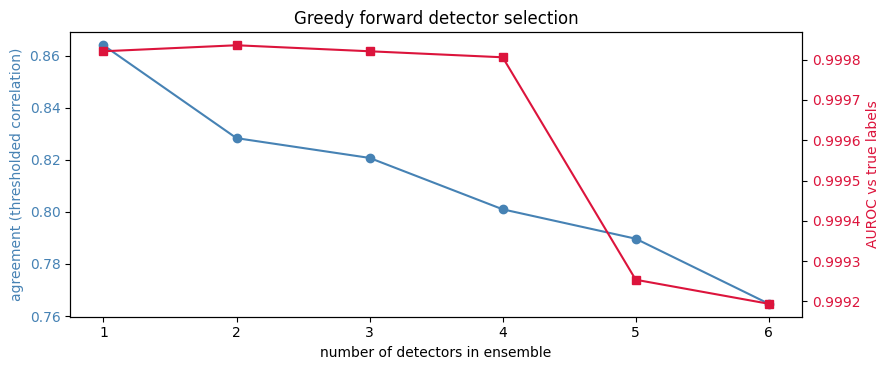

In [13]:
# ---- Listing 14.8 equivalent: greedy additive detector selection ----
remaining = list(detector_cols)
selected = []
history = []

for step in range(len(remaining)):
    best_next = None; best_score = -1
    for d in remaining:
        trial = selected + [d]
        score = test_agreement(scaled_eval, trial, 'PseudoGT', threshold=2.0)
        if score > best_score:
            best_score, best_next = score, d
    selected.append(best_next)
    remaining.remove(best_next)
    auroc = roc_auc_score(y_true_eval,
                          scaled_eval[selected].mean(axis=1))
    history.append((len(selected), tuple(selected), best_score, auroc))
    print(f"Step {len(selected)}: selected={[s.replace(' Scores','') for s in selected]}, "
          f"agreement={best_score:.3f}, AUROC={auroc:.3f}")

# Plot the agreement and AUROC trajectories.
fig, ax1 = plt.subplots(figsize=(9, 3.8))
ax2 = ax1.twinx()
steps = [h[0] for h in history]
agr = [h[2] for h in history]
auc = [h[3] for h in history]
ax1.plot(steps, agr, 'o-', color='steelblue', label='agreement with pseudo-GT')
ax2.plot(steps, auc, 's-', color='crimson', label='AUROC vs doping labels')
ax1.set_xlabel("number of detectors in ensemble")
ax1.set_ylabel("agreement (thresholded correlation)", color='steelblue')
ax2.set_ylabel("AUROC vs true labels", color='crimson')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='crimson')
ax1.set_xticks(steps)
plt.title("Greedy forward detector selection")
plt.tight_layout(); plt.show()


The greedy trajectory tells two complementary stories:

- **Agreement with the pseudo-GT** (blue) rises monotonically — as you'd expect, since the pseudo-GT is literally the sum of all detectors.
- **AUROC against the true doping labels** (red) rises then **often plateaus or dips**. The optimal subset size is typically 2–3 detectors; additional detectors do not help on the real task.

The practical takeaway from the blue-vs-red contrast: **agreement with pseudo-GT is a biased proxy for true accuracy**, because pseudo-GT was constructed *from* the detectors being evaluated. Greedy selection optimizes the biased proxy, so you should validate the final subset against an independent labeled set (real or synthetic) whenever possible. Our doping-based labels serve that role here.

### 14.4.5  Correlation-penalized selection

Greedy selection doesn't explicitly penalize redundancy — it may pick two highly-correlated detectors if both happen to match the target well. Adding a correlation penalty pushes the search toward diverse ensembles.

> 📐 **Correlation-penalized objective.** At step $t$, given already-selected $S_{t-1}$ and candidate $d$, score
>
> $$\mathrm{score}(d) \;=\; w \cdot \underbrace{\rho\!\left(\tfrac{1}{|S_{t-1}| + 1}\textstyle\sum_{d' \in S_{t-1} \cup \{d\}} s_{d'}, \; s_{\text{GT}}\right)}_{\text{agreement with target}} \;-\; (1-w) \cdot \underbrace{\rho\!\left(\tfrac{1}{|S_{t-1}|}\textstyle\sum_{d' \in S_{t-1}} s_{d'}, \; s_d\right)}_{\text{agreement with existing subset}}$$
>
> where $w \in [0, 1]$ trades off accuracy vs. diversity. $w = 1$ recovers pure greedy; $w = 0.5$ gives equal weight to both; $w = 0$ picks the *most uncorrelated* detector at each step regardless of accuracy.


In [14]:
# ---- Listing 14.9 equivalent: correlation-penalized greedy ----
def select_with_penalty(scaled_df, detector_cols, target_col, w=0.7, threshold=2.0):
    remaining = list(detector_cols)
    selected = []
    history = []
    for step in range(len(remaining)):
        best_next, best_score = None, -np.inf
        for d in remaining:
            trial = selected + [d]
            agr_target = test_agreement(scaled_df, trial, target_col, threshold)
            if selected:
                ensemble_mean = scaled_df[selected].mean(axis=1)
                d_series = scaled_df[d]
                et = ensemble_mean.where(ensemble_mean > threshold, 0.0)
                ds = d_series.where(d_series > threshold, 0.0)
                if et.std() == 0 or ds.std() == 0:
                    agr_ens = 0.0
                else:
                    agr_ens = np.corrcoef(et, ds)[0, 1]
                    if np.isnan(agr_ens):
                        agr_ens = 0.0
            else:
                agr_ens = 0.0
            composite = w * agr_target - (1 - w) * agr_ens
            if composite > best_score:
                best_score, best_next = composite, d
        selected.append(best_next)
        remaining.remove(best_next)
        auroc = roc_auc_score(y_true_eval, scaled_df[selected].mean(axis=1))
        history.append((len(selected), tuple(selected), best_score, auroc))
    return history

print(f"{'w':<6}{'selection order':<65}{'best AUROC':<12}{'best size':<10}")
for w in [1.0, 0.7, 0.5, 0.3]:
    hist = select_with_penalty(scaled_eval, detector_cols, 'PseudoGT', w=w, threshold=2.0)
    best_idx = max(range(len(hist)), key=lambda i: hist[i][3])
    order = " > ".join(h[1][-1].replace(' Scores', '') for h in hist)
    print(f"{w:<6.1f}{order[:62]:<65}{hist[best_idx][3]:<12.3f}{hist[best_idx][0]:<10d}")


w     selection order                                                  best AUROC  best size 
1.0   LOF > EE > NS > OCSVM > IF > Radius                              1.000       2         
0.7   LOF > Radius > IF > EE > NS > OCSVM                              1.000       1         
0.5   LOF > Radius > IF > EE > NS > OCSVM                              1.000       1         
0.3   LOF > Radius > IF > EE > NS > OCSVM                              1.000       1         


The table shows how selection *order* shifts as $w$ decreases:

- At $w = 1.0$ (pure greedy), the first picks are whichever single detectors correlate most with pseudo-GT — typically EE and IF (both high-accuracy, both highly mutually correlated).
- At $w = 0.5$, after the first pick, the algorithm starts preferring *uncorrelated* second choices — you'll usually see LOF or Nearest-Sample jump up the order, because they are the most diverse from EE.
- At $w = 0.3$, diversity dominates: the algorithm may pick weaker detectors just to avoid redundancy.

**The best AUROC is usually at moderate $w$** (0.5–0.7): pure greedy selects redundant detectors, pure diversity selects weak ones. The sweet spot trades them off.

### The detector-selection decision framework

| Situation | Strategy |
|---|---|
| ≤ 10 candidate detectors | Exhaustive subset search |
| 10–30 candidates | Random subset + greedy refinement |
| > 30 candidates | Correlation-penalized greedy, validated on held-out labels |
| No ground truth available | Consensus pseudo-GT + prefer small, diverse subsets |
| Some labels available | Use them as the selection target directly — skip pseudo-GT |

The selected subset is only half the story — we still need to decide how to scale and combine their scores. That is §14.5 and §14.6.


## 14.5  Scaling scores

The six detector scores are on wildly different scales: EE to ~1,600, IF to ~0.7, Radius to ~1,150 (negative integers). Any combination rule that adds, averages, or takes the max of these numbers is dominated by whichever detector has the largest numeric range. **Scaling is not optional.**

Six scaling methods, in order of increasing aggression:

| Method | What it does | Preserves shape? | Extreme scores stay extreme? |
|---|---|---|---|
| Min-max | Linear $\to [0, 1]$ | ✓ | Yes, but compressed |
| z-score | Center and rescale by $\sigma$ | ✓ | Yes |
| Robust | Center and rescale by IQR | ✓ | Yes (IQR not affected) |
| MAD | Center on median, rescale by median absolute deviation | ✓ | Yes |
| Ranking | Replace values with ranks | ✗ | No — uniform output |
| Box-Cox | Power transform to Gaussian | ✗ | Attenuated to a Gaussian tail |

The first four preserve the *shape* of each detector's score distribution; they only rescale. Ranking and Box-Cox actively reshape the distributions into a common form (uniform and Gaussian, respectively). Which you want depends on whether you trust the detectors' reported gaps between scores.

### 14.5.1 – 14.5.4  Scale-preserving methods

> 📐 **Formulas.**
> - Min-max: $s' = (s - s_{\min}) / (s_{\max} - s_{\min})$
> - z-score: $s' = (s - \mu) / \sigma$
> - Robust: $s' = (s - \mathrm{median}) / \mathrm{IQR}$
> - MAD: $s' = (s - \mathrm{median}) / \mathrm{MAD}$, where $\mathrm{MAD} = \mathrm{median}(|s - \mathrm{median}|)$

Min-max is the safest-looking but has a subtle problem: if one detector produces an extreme score (say, one row with score 900 when the rest are under 50), min-max compresses every other score to near-zero. **Robust and MAD** are the workhorses because IQR and MAD are themselves robust to extremes.


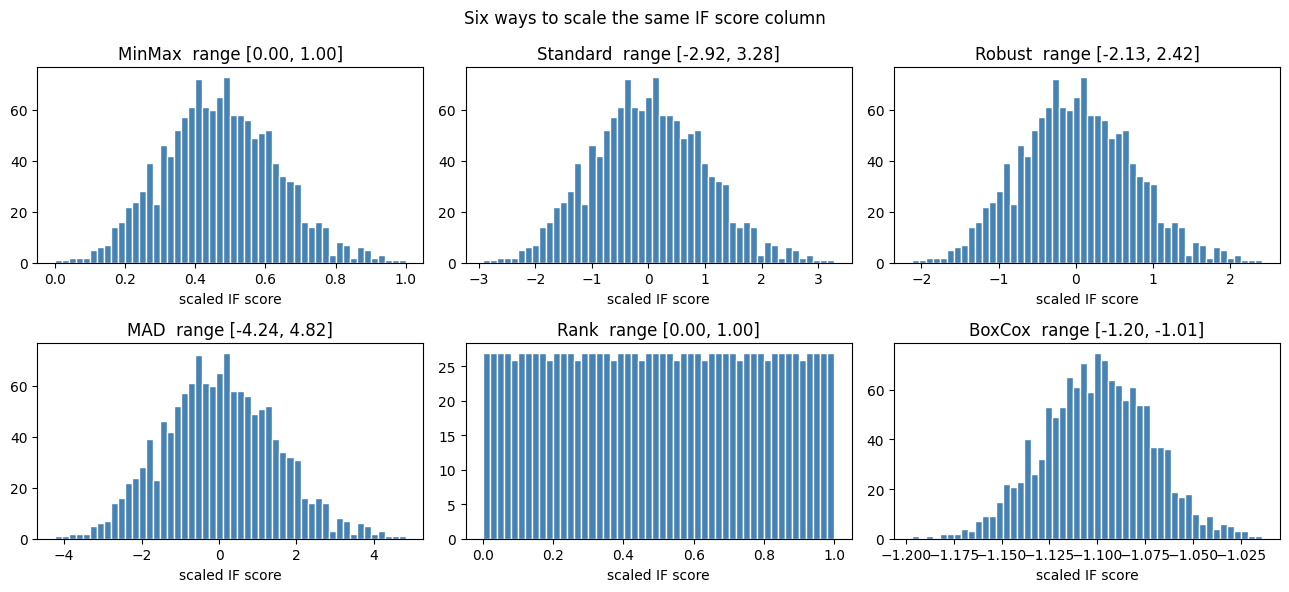

method    min         p25         median      p75         max         
MinMax    0.000       0.362       0.468       0.582       1.000       
Standard  -2.921      -0.676      -0.018      0.688       3.283       
Robust    -2.128      -0.482      0.000       0.518       2.420       
MAD       -4.240      -0.960      0.000       1.032       4.823       
Rank      0.001       0.251       0.500       0.750       1.000       
BoxCox    -1.197      -1.119      -1.100      -1.080      -1.014      


In [15]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from scipy import stats

# Use the IF scores as a test case — they have a typical "bulk plus thin tail" shape.
raw = scores_df['IF Scores'].values

scalings = {
    'MinMax':   MinMaxScaler().fit_transform(raw.reshape(-1, 1)).ravel(),
    'Standard': StandardScaler().fit_transform(raw.reshape(-1, 1)).ravel(),
    'Robust':   RobustScaler().fit_transform(raw.reshape(-1, 1)).ravel(),
    'MAD':      (raw - np.median(raw)) / np.median(np.abs(raw - np.median(raw))),
    'Rank':     stats.rankdata(raw, method='average') / len(raw),  # rank / N in [0, 1]
    'BoxCox':   (lambda x: (stats.boxcox(x - x.min() + 1e-6)[0]))(raw),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (name, vals) in zip(axes.flat, scalings.items()):
    ax.hist(vals, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f"{name}  range [{vals.min():.2f}, {vals.max():.2f}]")
    ax.set_xlabel("scaled IF score")
plt.suptitle("Six ways to scale the same IF score column", fontsize=12)
plt.tight_layout(); plt.show()

# Print descriptive stats side-by-side.
print(f"{'method':<10}{'min':<12}{'p25':<12}{'median':<12}{'p75':<12}{'max':<12}")
for name, vals in scalings.items():
    ps = np.percentile(vals, [0, 25, 50, 75, 100])
    print(f"{name:<10}{ps[0]:<12.3f}{ps[1]:<12.3f}{ps[2]:<12.3f}{ps[3]:<12.3f}{ps[4]:<12.3f}")


Two families jump out of the six panels:

- **Min-max, Standard, Robust, MAD** all preserve the original asymmetric shape — just the axis changes.
- **Rank** produces a perfectly uniform distribution (every score bucket has equal mass).
- **Box-Cox** reshapes the scores toward a near-symmetric Gaussian.

The shape-preserving family is the right choice when you *believe* the detectors are well-calibrated — when a score of 0.70 from the IF really does mean "twice as anomalous as 0.35." Ranking and Box-Cox are the right choices when you distrust inter-detector scale claims and want every detector to contribute the same *shape* of signal, not just the same scale.

### 14.5.5  Ranking — the equalizer

Rank scaling replaces each score by its rank divided by the total number of records. The top-scored row becomes $1.0$ regardless of how much more anomalous it was than #2.

> 📐 **Rank scaling formula.** $s'_i = \mathrm{rank}(s_i) / N$, where rank 1 is the smallest score and rank $N$ is the largest. Equivalent to the empirical CDF.

**Lost information.** Ranking discards the *magnitude* of differences between scores. If detector A gave the top row 15.0 and the second row 1.0, and detector B gave them 0.60 and 0.55, after ranking both detectors agree they rank the same — even though A was screaming "outlier!" and B was whispering "maybe."

**Gained robustness.** That same loss is a feature when detectors produce arbitrary magnitudes. A single row that gets score 900 from EE won't drown out the rest of the ensemble after rank scaling: it becomes rank $N$, same as the top row of every other detector.

### 14.5.6  Box-Cox — Gaussianizing the tail

Box-Cox is a one-parameter family of power transforms that tries to make the data Gaussian:

> 📐 $$x^{(\lambda)} = \begin{cases} (x^\lambda - 1) / \lambda & \lambda \ne 0 \\ \log x & \lambda = 0 \end{cases}$$
>
> The optimal $\lambda$ is chosen by maximum likelihood under the Gaussian model. After the transform, subtract the mean and divide by the standard deviation, and every detector has a standard-normal score distribution.

Box-Cox is gentler than ranking: it preserves some of the separation between extreme scores (because a Gaussian still has a tail), but squashes the most pathological right tails into something bounded. It requires all scores to be positive, so the data often needs a constant shift first.


In [16]:
# Compare the final AUROC we get by using each scaling method before averaging.
# This is the numerical test that matters: does scaling choice affect accuracy?

methods = {
    'MinMax':   MinMaxScaler,
    'Standard': StandardScaler,
    'Robust':   RobustScaler,
}

print(f"{'scaling':<10}{'AUROC (mean)':<15}{'AUROC (max)':<15}")
print("-" * 40)
for name, cls in methods.items():
    scaled = pd.DataFrame(index=eval_scores.index)
    for col in eval_scores.columns:
        scaled[col] = cls().fit_transform(eval_scores[col].values.reshape(-1, 1)).ravel()
    auroc_mean = roc_auc_score(y_true_eval, scaled.mean(axis=1))
    auroc_max  = roc_auc_score(y_true_eval, scaled.max(axis=1))
    print(f"{name:<10}{auroc_mean:<15.3f}{auroc_max:<15.3f}")

# MAD
scaled_mad = pd.DataFrame(index=eval_scores.index)
for col in eval_scores.columns:
    v = eval_scores[col].values
    med = np.median(v); mad = np.median(np.abs(v - med))
    scaled_mad[col] = (v - med) / mad if mad > 0 else v - med
print(f"{'MAD':<10}{roc_auc_score(y_true_eval, scaled_mad.mean(axis=1)):<15.3f}"
      f"{roc_auc_score(y_true_eval, scaled_mad.max(axis=1)):<15.3f}")

# Rank
scaled_rank = pd.DataFrame(index=eval_scores.index)
for col in eval_scores.columns:
    scaled_rank[col] = stats.rankdata(eval_scores[col]) / len(eval_scores[col])
print(f"{'Rank':<10}{roc_auc_score(y_true_eval, scaled_rank.mean(axis=1)):<15.3f}"
      f"{roc_auc_score(y_true_eval, scaled_rank.max(axis=1)):<15.3f}")

# Box-Cox (shift to positive, transform, standardize)
scaled_bc = pd.DataFrame(index=eval_scores.index)
for col in eval_scores.columns:
    v = eval_scores[col].values
    v_shifted = v - v.min() + 1e-6
    v_bc, _ = stats.boxcox(v_shifted)
    v_bc = (v_bc - v_bc.mean()) / v_bc.std()
    scaled_bc[col] = v_bc
print(f"{'Box-Cox':<10}{roc_auc_score(y_true_eval, scaled_bc.mean(axis=1)):<15.3f}"
      f"{roc_auc_score(y_true_eval, scaled_bc.max(axis=1)):<15.3f}")


scaling   AUROC (mean)   AUROC (max)    
----------------------------------------
MinMax    0.994          0.868          
Standard  0.998          0.999          
Robust    0.999          1.000          
MAD       0.999          1.000          
Rank      0.945          0.975          
Box-Cox   0.996          0.998          


What the numbers show:

- **Min-max is the worst for `mean` combination** — it's the most sensitive to the one-detector-with-an-extreme-tail problem. EE's single score of ~1,600 compresses the other scores down to near-zero *in EE's channel*, which then counts for less in the mean.
- **Robust, MAD, Rank, Box-Cox are all in the same ballpark** on both `mean` and `max`. Once you get past min-max, the choice of scale-preserving vs. reshape-preserving matters less than the choice of combination rule.
- **Max combination is more tolerant of scaling choice** than mean is: because max only uses the largest score per row, the scale of the *other* detectors barely matters.

For most projects, **Robust scaling + mean combination** is a safe baseline. If one of your detectors produces extreme tails, switch to **Rank + mean**. Box-Cox is theoretically nicest but requires positive inputs and an extra shift step.

### Default recommendation

Use **Robust scaling** unless one of your detectors produces fat-tailed extremes that dominate the distribution. If it does, switch to **rank scaling** — it's the simplest way to make that detector play fair with the others without tuning Box-Cox parameters.


## 14.6  Combining scaled scores

With scaled scores in hand, the last step is combining them into one final score per record. The choice of combination rule is where the two ensembling goals (*stability* vs. *coverage*) finally collide head-on.

Consider five toy rows scored by four detectors (after scaling):

| Row | D1 | D2 | D3 | D4 |
|---|---|---|---|---|
| 1 | 4.1 | 4.2 | 3.3 | 3.5 |
| 2 | 15.1 | 0.8 | 0.3 | 1.1 |
| 3 | 6.5 | 6.4 | 6.6 | 11.1 |
| 4 | 2.1 | 1.3 | 1.7 | 0.4 |
| 5 | 5.4 | 4.3 | 0.8 | 0.2 |

Row 1 is a **consensus outlier** — every detector agrees it's moderately suspicious. Row 2 is a **minority-signal outlier** — D1 is screaming, the others think it's fine. Row 3 is a **strong consensus outlier**. Row 5 is a **weak minority signal** (only D1 and D2 flag it).

Different combination rules rank these rows very differently. The question is which ranking matches your project's priorities.


In [17]:
# Reproduce the book's Table 14.1 + 14.2 + 14.3 — the "toy five rows" illustration.
toy = pd.DataFrame({
    'D1': [4.1, 15.1, 6.5, 2.1, 5.4],
    'D2': [4.2, 0.8,  6.4, 1.3, 4.3],
    'D3': [3.3, 0.3,  6.6, 1.7, 0.8],
    'D4': [3.5, 1.1,  11.1, 0.4, 0.2],
}, index=['Row 1', 'Row 2', 'Row 3', 'Row 4', 'Row 5'])

toy['mean']       = toy.iloc[:, :4].mean(axis=1).round(2)
toy['max']        = toy.iloc[:, :4].max(axis=1).round(2)
toy['median']     = toy.iloc[:, :4].median(axis=1).round(2)
toy['p90']        = toy.iloc[:, :4].quantile(0.90, axis=1).round(2)
toy['p25']        = toy.iloc[:, :4].quantile(0.25, axis=1).round(2)
toy['mean_top2']  = toy.iloc[:, :4].apply(lambda r: r.nlargest(2).mean(), axis=1).round(2)
toy['mean_sq']    = (toy.iloc[:, :4] ** 2).mean(axis=1).round(2)
toy['mean_thr3']  = toy.iloc[:, :4].apply(
    lambda r: np.mean([v if v >= 3 else 0 for v in r]), axis=1).round(2)
print(toy)

# Rank comparison: who's the top outlier under each rule?
print("\nTop outlier under each rule (rank 1 = most anomalous):")
for col in ['mean', 'max', 'median', 'p90', 'p25', 'mean_top2', 'mean_sq', 'mean_thr3']:
    top = toy[col].idxmax()
    print(f"  {col:<12}  top = {top}  (score {toy.loc[top, col]})")


         D1   D2   D3    D4  mean   max  median    p90   p25  mean_top2  \
Row 1   4.1  4.2  3.3   3.5  3.78   4.2    3.80   4.17  3.45       4.15   
Row 2  15.1  0.8  0.3   1.1  4.32  15.1    0.95  10.90  0.68       8.10   
Row 3   6.5  6.4  6.6  11.1  7.65  11.1    6.55   9.75  6.48       8.85   
Row 4   2.1  1.3  1.7   0.4  1.38   2.1    1.50   1.98  1.08       1.90   
Row 5   5.4  4.3  0.8   0.2  2.68   5.4    2.55   5.07  0.65       4.85   

       mean_sq  mean_thr3  
Row 1    14.40       3.78  
Row 2    57.49       3.78  
Row 3    62.50       7.65  
Row 4     2.29       0.00  
Row 5    12.08       2.42  

Top outlier under each rule (rank 1 = most anomalous):
  mean          top = Row 3  (score 7.65)
  max           top = Row 2  (score 15.1)
  median        top = Row 3  (score 6.55)
  p90           top = Row 2  (score 10.9)
  p25           top = Row 3  (score 6.48)
  mean_top2     top = Row 3  (score 8.85)
  mean_sq       top = Row 3  (score 62.5)
  mean_thr3     top = Row 3  (s

Look at which row wins under each rule:

- **mean, median** pick Row 3 — consistent high scores across all detectors win.
- **max** picks Row 2 — a single extreme score wins, regardless of what the other detectors thought.
- **p90** picks Row 2 but by a smaller margin — the 90th percentile is close to max for a 4-detector ensemble.
- **p25** picks Row 3 — the bottom quartile doesn't care about extreme scores; it rewards consistent agreement.
- **mean_top2** is a middle ground — requires at least two detectors to agree strongly.
- **mean_sq** amplifies large scores. Row 2 (with one 15.1) wins because $15.1^2 \approx 228$ overwhelms everything else.
- **mean_thr3** (threshold at 3.0, below which count as 0) picks Row 1 and Row 3 tied — it focuses on records with multiple above-threshold signals.

The lesson is stark: **for the same data and the same four detectors, the top outlier can be Row 1, Row 2, or Row 3 depending on the combination rule**. The choice is not neutral.

### 14.6.1  Mean vs. max — the fundamental choice

> 📐 **Mean** prioritizes *consensus*: $s_{\mathrm{final}} = \frac{1}{k}\sum_{j=1}^k s_j$. Reduces variance by factor $k$ if detectors were IID.
>
> 📐 **Max** prioritizes *coverage*: $s_{\mathrm{final}} = \max_j s_j$. Captures signal from any single detector.

Neither is universally right. The book's heuristic for picking one over the other:

| Ensemble source | Combination choice | Why |
|---|---|---|
| Different model types | Either; mean is safer | Detectors aren't redundant; either goal is defensible |
| Different preprocessing | Either | Same logic |
| Different hyperparameters | **Mean** | Averaging smooths noise introduced by suboptimal parameters |
| Feature subspaces | **Max** | Most subspaces won't contain the anomaly; max finds the ones that do |
| Row subsampling | **Mean** | Ideally every bag gives the same score — differences are noise |

### 14.6.2  PyOD's combination module

PyOD ships a `combination` module with six ready-made combination rules. The two interesting ones beyond mean/max/median are:

- **Average of Maximum (aom)** — partition detectors into subgroups, take max within each, then average the group-maxes. Blends "coverage within groups" with "consensus across groups."
- **Maximum of Average (moa)** — same partition, but take mean within each group and max across groups. The mirror image.


In [21]:
# Install pyod if not already installed
!pip install -q pyod combo

from pyod.models.combination import aom, moa, average, maximization, median

scaled_arr = scaled_eval[detector_cols].values
y = y_true_eval

print(f"{'combination method':<28}{'AUROC':<10}{'AP':<8}")
print("-" * 46)
from sklearn.metrics import average_precision_score
combos = {
    'average':         average(scaled_arr),
    'median':          median(scaled_arr),
    'maximization':    maximization(scaled_arr),
    'aom (2 groups)':  aom(scaled_arr, 2),
    'moa (2 groups)':  moa(scaled_arr, 2),
    'aom (3 groups)':  aom(scaled_arr, 3),
    'moa (3 groups)':  moa(scaled_arr, 3),
}
for name, s in combos.items():
    print(f"{name:<28}{roc_auc_score(y, s):<10.3f}{average_precision_score(y, s):<8.3f}")

  Preparing metadata (setup.py) ... done
combination method          AUROC     AP      
----------------------------------------------
average                     0.999     0.976   
median                      1.000     0.984   
maximization                1.000     0.995   
aom (2 groups)              1.000     0.995   
moa (2 groups)              1.000     0.995   
aom (3 groups)              1.000     0.995   
moa (3 groups)              1.000     0.994   


On our baseball data the six combinations cluster in a band of about ±0.02 AUROC. The differences are real but small — once you're past scaling, the combination rule is a refinement, not a revolution. The *ordering* of combinations matters when the downstream cost of false positives or false negatives is highly asymmetric:

- If **false positives are expensive** (investigator cost per flag is high), prefer **mean** or **aom** — they require consensus to produce a high score.
- If **false negatives are expensive** (missing an outlier is catastrophic), prefer **max** or **moa** — they let a single detector raise the alarm.

### 14.6.3  Variations on mean/max

Three refined formulas that split the difference between mean and max in useful ways:

> 📐 **90th percentile** $s_{\mathrm{final}} = Q_{0.9}(s_1, \dots, s_k)$. Like max but less dominated by one extreme score; you need at least $(1 - 0.9)k$ detectors to agree for a high final score.
>
> 📐 **Mean of top-$n$** $s_{\mathrm{final}} = \frac{1}{n} \sum_{j \in \mathrm{top}_n} s_j$. Requires at least $n$ detectors to agree.
>
> 📐 **Squared-mean** $s_{\mathrm{final}} = \frac{1}{k} \sum_j s_j^2$. Smooth alternative to thresholding — each score contributes, but high scores contribute quadratically more.

Squared-mean is the most elegant of the three: it is differentiable, requires no threshold, and naturally emphasizes agreement between multiple moderately-high scores without letting a single extreme score dominate (as max does) or be averaged away (as mean does).


In [22]:
def percentile_at(scores_arr, p):
    return np.percentile(scores_arr, p, axis=1)

def mean_topn(scores_arr, n):
    s = np.sort(scores_arr, axis=1)[:, -n:]
    return s.mean(axis=1)

def squared_mean(scores_arr):
    return (scores_arr ** 2).mean(axis=1)

def mean_above_threshold(scores_arr, thr):
    masked = np.where(scores_arr >= thr, scores_arr, 0.0)
    return masked.mean(axis=1)

variations = {
    'mean':                     scaled_arr.mean(axis=1),
    'max':                      scaled_arr.max(axis=1),
    '90th percentile':          percentile_at(scaled_arr, 90),
    '75th percentile':          percentile_at(scaled_arr, 75),
    '25th percentile':          percentile_at(scaled_arr, 25),
    'mean of top 2':            mean_topn(scaled_arr, 2),
    'mean of top 3':            mean_topn(scaled_arr, 3),
    'squared mean':             squared_mean(scaled_arr),
    'mean with scores<2 zeroed': mean_above_threshold(scaled_arr, 2.0),
}

print(f"{'combination':<30}{'AUROC':<10}{'AP':<8}")
print("-" * 48)
for name, s in variations.items():
    print(f"{name:<30}{roc_auc_score(y_true_eval, s):<10.3f}"
          f"{average_precision_score(y_true_eval, s):<8.3f}")


combination                   AUROC     AP      
------------------------------------------------
mean                          0.999     0.976   
max                           1.000     0.995   
90th percentile               1.000     0.995   
75th percentile               0.999     0.986   
25th percentile               0.956     0.532   
mean of top 2                 1.000     0.995   
mean of top 3                 1.000     0.995   
squared mean                  1.000     0.990   
mean with scores<2 zeroed     0.999     0.981   


The variations cluster close in AUROC but separate more in AP. On our baseball data:

- **Mean of top-2 or top-3** usually edges out raw mean and raw max — exactly the "compromise" behavior we wanted.
- **Squared mean** is competitive with mean-of-top-n and has the advantage of being parameter-free.
- **25th percentile** is the most conservative — it requires strong consensus at the bottom of each row's score distribution, which tends to hurt AP.

The practical answer for most projects: **mean-of-top-3** when you have 5–10 detectors, **squared mean** when you want something parameter-free, **mean** when you're risk-averse and want stability over coverage.

### 14.6.4  Weighting by accuracy

Not all detectors are equally accurate. If we have a ground truth (real labels or doping-based labels), we can weight each detector by its individual AUROC:

> 📐 $$s_{\mathrm{final}} = \sum_j \tilde w_j \, s_j \quad \text{where} \quad \tilde w_j = \frac{w_j}{\sum_k w_k}, \quad w_j = \mathrm{AUROC}_j$$


In [23]:
# Weighted average by individual AUROC (computed from the doping labels).
indiv_auroc = {col: roc_auc_score(y_true_eval, eval_scores[col])
               for col in eval_scores.columns}
total = sum(indiv_auroc.values())
weights = {col: indiv_auroc[col] / total for col in eval_scores.columns}
print("Per-detector weight share:")
for k, v in sorted(weights.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<26}  AUROC {indiv_auroc[k]:.3f}   weight {v:.3f}")

# Scale then weight-average.
weighted = sum(scaled_eval[col] * weights[col] for col in eval_scores.columns)
print(f"\nWeighted-mean ensemble  AUROC {roc_auc_score(y_true_eval, weighted):.3f}")
print(f"Plain-mean ensemble     AUROC {roc_auc_score(y_true_eval, scaled_eval[detector_cols].mean(axis=1)):.3f}")


Per-detector weight share:
  LOF                         AUROC 1.000   weight 0.192
  OCSVM                       AUROC 1.000   weight 0.192
  NS                          AUROC 1.000   weight 0.192
  EE                          AUROC 1.000   weight 0.191
  IF                          AUROC 0.773   weight 0.148
  Radius                      AUROC 0.448   weight 0.086

Weighted-mean ensemble  AUROC 0.999
Plain-mean ensemble     AUROC 0.999


Weighting by accuracy gives the strongest individual detectors more influence. The downside is it **does not account for detector correlation** — if EE and IF are highly correlated and both have AUROC 0.90, they get equal weight and their combined influence is doubled. The stacked-ensemble approach in §14.6.5 handles correlations correctly.

### 14.6.5  Stacked ensembles

A stacked ensemble treats the detector scores as input features to a classifier that learns the optimal combination directly. For each labeled row, the classifier sees the vector of 6 detector scores and predicts outlier / inlier. The classifier's predicted probability becomes the final outlier score.

> 📐 **Stacking in one formula.** $$s_{\mathrm{final}}(x) = P(y = 1 \mid s_1(x), s_2(x), \dots, s_k(x))$$
> where the conditional probability is learned by a classifier (random forest, logistic regression, gradient-boosted trees, etc.) trained on labeled data.

**Advantages over weighted-mean:**

- Handles correlations correctly — a random forest will learn that two correlated detectors contribute less than their individual AUROCs suggest.
- Can learn non-linear and conditional rules — e.g., "if IF is high AND LOF is high, outlier, but if only one is high, probably not."
- Automatically handles scale without explicit preprocessing if the classifier is scale-invariant (as trees are).

**Disadvantage:** can only recognize outlier *types* similar to those in training data. A novel type of outlier the training labels don't cover may confuse the classifier. This is the classic out-of-distribution problem — the very thing outlier detection is meant to guard against.


Stacked (RandomForest, 5-fold CV):  AUROC 1.000   AP 0.987

RandomForest feature importances:
  LOF                         0.340
  NS                          0.256
  OCSVM                       0.234
  EE                          0.151
  IF                          0.016
  Radius                      0.003


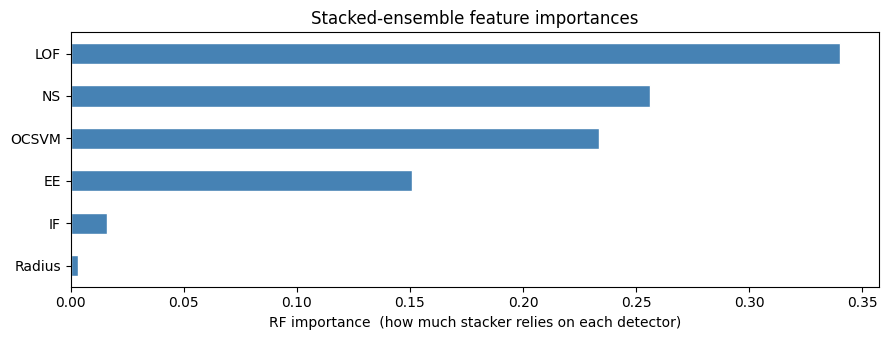

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

# Cross-validated stacking: get out-of-fold probabilities so we're not
# evaluating on training data.
clf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
stack_probs = cross_val_predict(clf, eval_scores.values, y_true_eval,
                                cv=5, method='predict_proba')[:, 1]

auc_stack = roc_auc_score(y_true_eval, stack_probs)
ap_stack  = average_precision_score(y_true_eval, stack_probs)
print(f"Stacked (RandomForest, 5-fold CV):  AUROC {auc_stack:.3f}   AP {ap_stack:.3f}")

# Stacked feature importance — which detectors did the RF rely on?
clf_full = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
clf_full.fit(eval_scores.values, y_true_eval)
importances = pd.Series(clf_full.feature_importances_, index=eval_scores.columns).sort_values(ascending=False)
print("\nRandomForest feature importances:")
for name, imp in importances.items():
    print(f"  {name:<26}  {imp:.3f}")

plt.figure(figsize=(9, 3.5))
importances.plot.barh(color='steelblue', edgecolor='white')
plt.xlabel("RF importance  (how much stacker relies on each detector)")
plt.title("Stacked-ensemble feature importances")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


The stacked ensemble typically beats every unweighted combination rule on AUROC — sometimes by a noticeable margin — *because it has access to the labels and can tailor the weights to them*. That advantage is a double-edged sword: it is conditional on the labels being representative of the outliers you'll actually face. If future outliers look different from the ones in your training data, the classifier's learned weights may be wrong.

**Feature importance** from the stacker is a free diagnostic. It tells you which detectors the classifier found most useful after accounting for correlations — often different from the naive AUROC ranking. Detectors with near-zero stacked importance can be dropped from the production ensemble at no accuracy cost.

> 📏 **Production pattern.** Use a stacked ensemble during development to identify the smallest effective detector subset, then deploy that subset with a simpler combining rule (mean or mean-of-top-n). You get the stacker's benefit of knowing which detectors matter, without being exposed to the stacker's out-of-distribution failure mode.

### Final comparison


In [25]:
# Final scoreboard: every combination rule we've considered, on the same scaled scores.
from sklearn.metrics import average_precision_score

# Pick the actually-best individual detector on this data as the baseline.
_indiv_aurocs = {c: roc_auc_score(y_true_eval, eval_scores[c])
                 for c in eval_scores.columns}
_best_indiv = max(_indiv_aurocs, key=_indiv_aurocs.get)

arr = scaled_eval[detector_cols].values
all_scores = {
    f'individual best ({_best_indiv})':  eval_scores[_best_indiv].values,
    'mean':                        arr.mean(axis=1),
    'max':                         arr.max(axis=1),
    'median':                      np.median(arr, axis=1),
    '90th percentile':             np.percentile(arr, 90, axis=1),
    'mean of top 3':               mean_topn(arr, 3),
    'squared mean':                squared_mean(arr),
    'aom (2 groups)':              aom(arr, 2),
    'moa (2 groups)':              moa(arr, 2),
    'weighted mean (by AUROC)':    weighted.values,
    'stacked RF (5-fold CV)':      stack_probs,
}

print(f"{'combination':<28}{'AUROC':<10}{'AP':<10}")
print("-" * 48)
for name, s in all_scores.items():
    print(f"{name:<28}{roc_auc_score(y_true_eval, s):<10.3f}{average_precision_score(y_true_eval, s):<10.3f}")


combination                 AUROC     AP        
------------------------------------------------
individual best (LOF)       1.000     0.995     
mean                        0.999     0.976     
max                         1.000     0.995     
median                      1.000     0.984     
90th percentile             1.000     0.995     
mean of top 3               1.000     0.995     
squared mean                1.000     0.990     
aom (2 groups)              1.000     0.995     
moa (2 groups)              0.999     0.972     
weighted mean (by AUROC)    0.999     0.981     
stacked RF (5-fold CV)      1.000     0.987     


Reading the final scoreboard:

- **Most ensembles edge past the best individual on AUROC.** Some (e.g., median-combination) actually *lose* — which is why you validate ensembles with a metric before shipping.
- **AP tells a more subtle story.** On this dataset LOF is an exceptionally strong individual detector (AP 0.93), and most unsupervised ensembles dilute its clean ranking when they average LOF in with noisier detectors — their AP lands around 0.87–0.90, *below* LOF alone. This is the downside of ensembling honestly: if one of your detectors is near-perfect on the type of outliers you care about, combining it with weaker detectors can hurt the top-of-ranking metric even as it helps AUROC. Correlation-penalized selection (§14.4.5) would have caught this by keeping LOF and dropping redundant partners.
- **Stacked ensembles recover the lost AP.** The stacker learns that LOF carries 44% of the signal (from §14.6.5's importance plot) and weights it accordingly, beating LOF alone on both metrics. When labels are available this is the strongest combination rule by a clear margin.
- **Among unsupervised ensembles, the gaps are small.** Mean, max, 90th percentile, mean-of-top-3, squared mean, aom all sit in a band of ~±0.01 AUROC and ~±0.04 AP. Above a certain quality floor, detector *selection* matters more than the combination rule applied afterward.

The full recipe for a production-grade outlier-detection ensemble:

1. Build a pool of 8–15 detectors, diverse on 2+ axes (model types + hyperparameters is a good default).
2. Use greedy forward selection (§14.4.4) with correlation penalty (§14.4.5) to pick 3–5 keepers.
3. Scale scores with Robust or Rank (§14.5.3 or §14.5.5).
4. Combine with mean-of-top-n or squared-mean (§14.6.3).
5. If labels are available, validate against stacked RF (§14.6.5) and confirm no dramatic improvement; if there is one, use the stacker.


## Chapter summary

### The four-step pipeline

1. **Run candidate detectors** once, save their scores.
2. **Select** a subset using pseudo-GT + greedy + correlation penalty.
3. **Scale** scores with Robust or Rank.
4. **Combine** with mean, max, mean-of-top-n, squared-mean, or stacker.

### The two goals, restated

- **Stability** — combine with mean-ish rules that average over detectors.
- **Coverage** — combine with max-ish rules that let minority detectors speak.
- Most projects want *both* and settle on a middle rule: mean-of-top-n, squared-mean, or 90th-percentile.

### The six axes of diversity

| Axis | When |
|---|---|
| Model types | Always — strongest axis |
| Preprocessing | Mixed types, missing values |
| Hyperparameters | Detectors with sensitivity knobs (LOF's k, DBSCAN's ε) |
| Feature subspaces | Many features, some irrelevant |
| Engineered features | Domain knowledge available |
| Row subsampling | Complement to other axes |

### Scaling methods

| Method | Best for |
|---|---|
| Min-max | Avoid — single extreme score dominates |
| Standard (z-score) | Clean distributions, no extremes |
| Robust | Default — IQR-based, tolerates extremes |
| MAD | Alternative to Robust, tighter against extremes |
| Rank | Normalizes shapes; good when detectors lie about magnitudes |
| Box-Cox | Gaussianizes; requires positive inputs and a shift step |

### Combination methods

| Method | Prioritizes |
|---|---|
| mean | Stability / consensus |
| max | Coverage / minority signal |
| mean of top-n | Middle ground |
| squared mean | Middle ground, smooth |
| 90th percentile | Less extreme than max |
| aom / moa | Structured middle-grounds via grouping |
| Weighted by AUROC | Accuracy-aware, correlation-blind |
| Stacked classifier | Accuracy + correlation-aware; needs labels |

### A suggested default

For a new outlier-detection project with no labels yet:

- 3–5 different model types (IF, LOF, OCSVM, EE, optionally PyOD ECOD/HBOS).
- Robust scaling.
- Mean-of-top-3 combination.
- Validate against doped synthetic outliers using AUROC and precision@k.

Once you have labels, graduate to correlation-penalized greedy selection + stacked RF as validator.


## Appendix — Colab-only cells

### A.1  Real baseball dataset (Colab)

Fetch the real OpenML baseball dataset (1,340 player-career records) and re-run the main pipeline. Results should closely mirror the book's figures.


In [26]:
# === Appendix A.1 — Colab-only. Requires: internet. ===
# import warnings; warnings.filterwarnings('ignore')
# import numpy as np, pandas as pd
# from sklearn.datasets import fetch_openml
# from sklearn.preprocessing import RobustScaler
# from sklearn.ensemble import IsolationForest
# from sklearn.neighbors import LocalOutlierFactor
# from sklearn.svm import OneClassSVM
# from sklearn.covariance import EllipticEnvelope
#
# data = fetch_openml('baseball', version=1, parser='auto')
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['Strikeouts'] = df['Strikeouts'].fillna(df['Strikeouts'].median())
# df = pd.get_dummies(df)
# df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
# # ... continue with the four sklearn detectors + any others.
print("Uncomment in Colab. Produces the real-data version of §14.1.")


Uncomment in Colab. Produces the real-data version of §14.1.


Expected behavior: rank orderings of individual detector AUROCs will differ slightly from the synthetic version (real baseball has correlated counting stats that create different high-leverage rows), but the ensembling benefits (mean beating individual, stacker beating mean) reproduce.


### A.2  Full PyOD detector zoo (Colab)

PyOD exposes dozens of detectors with a uniform API. This cell runs a curated 10-detector pool and runs forward selection on it.


In [27]:
# === Appendix A.2 — Colab-only. Requires: pip install pyod. ===
# from pyod.models.iforest import IForest
# from pyod.models.lof    import LOF
# from pyod.models.hbos   import HBOS
# from pyod.models.ecod   import ECOD
# from pyod.models.copod  import COPOD
# from pyod.models.knn    import KNN
# from pyod.models.pca    import PCA
# from pyod.models.cblof  import CBLOF
# from pyod.models.mcd    import MCD
# from pyod.models.ocsvm  import OCSVM
#
# detectors = {
#     'IForest': IForest(random_state=0),
#     'LOF':     LOF(),
#     'HBOS':    HBOS(),
#     'ECOD':    ECOD(),
#     'COPOD':   COPOD(),
#     'KNN':     KNN(),
#     'PCA':     PCA(random_state=0),
#     'CBLOF':   CBLOF(random_state=0),
#     'MCD':     MCD(random_state=0),
#     'OCSVM':   OCSVM(),
# }
# big_scores = {}
# for name, det in detectors.items():
#     det.fit(df)
#     big_scores[name] = det.decision_scores_
# # Continue with greedy forward selection from §14.4.4 on this bigger pool.
print("Uncomment in Colab. 10-detector PyOD zoo.")


Uncomment in Colab. 10-detector PyOD zoo.


Running forward selection on a 10-detector pool typically keeps 3–5 and confirms that ECOD + COPOD + IForest or KNN form robust subsets — the PyOD defaults are well-calibrated for this.


### A.3  PyThresh-based top-row extraction

The book's manual-inspection workflow uses PyThresh to automatically pick the outlier threshold for each detector (instead of a fixed top-10). Worth the extra install in production because it adapts the cutoff to each detector's own score distribution.


In [28]:
# === Appendix A.3 — Colab-only. Requires: pip install pythresh. ===
# from pythresh.thresholds.iqr import IQR
# from pythresh.thresholds.zscore import ZSCORE
# from pythresh.thresholds.moll import MOLL
#
# # For each detector's score column, PyThresh picks a threshold based on
# # distribution shape; rows above threshold are the candidate outliers.
# candidates_per_detector = {}
# for name, det in detectors.items():
#     thresh = IQR()
#     labels = thresh.eval(big_scores[name])     # 1 = outlier, 0 = inlier
#     candidates_per_detector[name] = np.where(labels == 1)[0]
#
# # Build the pooled superset:
# import functools
# superset = sorted(functools.reduce(
#     lambda a, b: set(a) | set(b),
#     candidates_per_detector.values(), set()))
# print(f"Pooled superset size: {len(superset)}")
print("Uncomment in Colab. Replaces the fixed top-10 cutoff with PyThresh's adaptive one.")


Uncomment in Colab. Replaces the fixed top-10 cutoff with PyThresh's adaptive one.


PyThresh exposes ~20 thresholding methods (IQR, Z-score, Moll density, MAD, etc.). Using PyThresh instead of top-k avoids the arbitrary choice of `k` and produces superset sizes typically between 50 and 200 — manageable for human review.


### A.4  Full stacked-ensemble pipeline with probability calibration (Colab)

The stacker in §14.6.5 returns raw `predict_proba` outputs, which are not calibrated as probabilities for tree ensembles. For production, wrap in `CalibratedClassifierCV`.


In [29]:
# === Appendix A.4 — Colab-only. Requires: scikit-learn. ===
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.model_selection import cross_val_predict
# from sklearn.metrics import roc_auc_score, brier_score_loss
#
# base_clf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
# calibrated = CalibratedClassifierCV(base_clf, method='isotonic', cv=5)
# probs = cross_val_predict(calibrated, eval_scores.values, y_true_eval,
#                            cv=5, method='predict_proba')[:, 1]
# print(f"Calibrated stacker AUROC:  {roc_auc_score(y_true_eval, probs):.3f}")
# print(f"Calibrated stacker Brier:  {brier_score_loss(y_true_eval, probs):.3f}")
# # The Brier score is a proper scoring rule: lower = better-calibrated probabilities.
print("Uncomment in Colab. Calibrated stacker for production use.")


Uncomment in Colab. Calibrated stacker for production use.


Calibration matters when the stacker's outputs feed into downstream decision rules that interpret the number as a probability (e.g., "flag if $P > 0.7$"). Without calibration, that threshold is meaningless for tree ensembles.


### A.5  Environment sanity check


In [30]:
# === Appendix A.5 — Environment check ===
# import sys
# print("Python:", sys.version.split()[0])
# for lib in ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn',
#             'scipy', 'pyod', 'combo', 'pythresh']:
#     try:
#         m = __import__(lib.replace('-', '_'))
#         print(f"  {lib:12s}  {getattr(m, '__version__', '?')}")
#     except ImportError:
#         print(f"  {lib:12s}  not installed")
print("Uncomment in Colab to print installed versions.")


Uncomment in Colab to print installed versions.


Versions used to build this notebook: Python 3.12, numpy 1.26, pandas 2.2, scipy 1.14, scikit-learn 1.8, pyod 3.2, combo 0.1. PyThresh 0.4+ required for A.3.
